<a href="https://colab.research.google.com/github/yeatescp01/INFO648/blob/main/Lesson_06/INFO_648_S25_Lesson_6_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Inference** focuses on understanding population-level patterns and relationships using sample data.
In this notebook, we used confidence intervals and hypothesis tests to quantify uncertainty about *population mean weekly earnings*, not individual outcomes.
These tools help us determine whether observed differences are likely due to random sampling or reflect real differences in the population.
Importantly, inference tells us about averages and uncertainty in parameters, but it does not tell us what any specific individual will earn.


In this excercise we want to determine if there is any difference in  the Winsored population mean between Bachelors Degrees and Masters Degrees.

In [ ]:
import pandas as pd

We will use the CPS with education data from your homework to compare the population means for weekly earnings between people with a gradaute degree and people with an undergraduate degree.

In [ ]:
df=pd.read_csv("/content/cps_with_education(1).csv")

Let's do a quick EDA to see if we have enough data.

In [ ]:
#df.head()
#df.describe()
df['education'].unique()

array(['Some College', 'Less than HS', "Bachelor's", "Associate's",
       "Master's", 'NIU / Child', 'Graduate / Professional',
       'High School'], dtype=object)

Remember there are a lot of not applicable Earnings, so let's remove them and scope the dataset to the sample we are conserned with.
We know that code 99999 is an error code in the data and we do not want people with 0 salary.

In [ ]:
#limit the data frame to remove errors, have actual salaries, and just the past couple of years
df_clean= df[(df['EARNWEEK2']<99999) &(df['EARNWEEK2']>100)&(df['YEAR']>2023)].copy()

In [ ]:
df_clean['education'].value_counts()

,count
education,
Master's,61338
Some College,61311
Graduate / Professional,38006
Associate's,33911
Bachelor's,26168
Less than HS,12890
High School,2778
NIU / Child,332


We want to compare the Earnings of Masters and Bachelors so let's make subset dataframes.

In [ ]:
masters=df_clean[df_clean['education']=="Master's"].copy()
bachelors=df_clean[df_clean['education']=="Bachelor's"].copy()

We can use a plot (which one) to assess if there is a difference betwen the two samples.

/tmp/ipykernel_1971/899771574.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box.boxplot([bachelors['EARNWEEK2'],masters['EARNWEEK2']], labels=["B","M"])


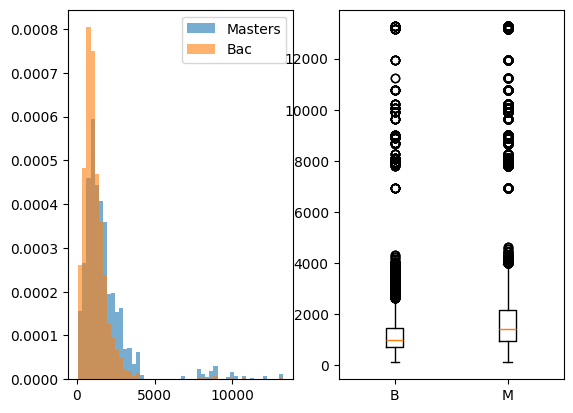

In [ ]:
import matplotlib.pyplot as plt

fig, (ax_hist, ax_box)=plt.subplots(1,2)

ax_hist.hist(masters['EARNWEEK2'], bins=50, label='Masters',density=True, alpha=.6)
ax_hist.hist(bachelors['EARNWEEK2'], bins=50,label='Bac', density=True, alpha=.6)
ax_hist.legend()

ax_box.boxplot([bachelors['EARNWEEK2'],masters['EARNWEEK2']], labels=["B","M"])
plt.show()


#Winsorization
To handle outliers, this analysis employs Winsorization at the [X]th and [Y]th percentiles, replacing extreme values with the nearest specified limits rather than removing them. This technique reduces the influence of extreme observations on the statistical results while maintaining the original sample size.

In [ ]:
#let's make make out cutoff points at the 95th quantile of EARNWEEK2 for each
b_cut=bachelors['EARNWEEK2'].quantile(.95)
m_cut=masters['EARNWEEK2'].quantile(.95)
print(b_cut,m_cut)

2500.0 3840.0


In [ ]:
# We will code this together, for each dataframe it is two steps:
#Create a new column called EARNWEEK2_w95 so we account for the fact we are cooking the books.
#If the EARNWEEK2 value at the location is greater than the cutoff value, change the EARNWEEK2_w95 columns value
bachelors['EARNWEEK2_w95']=bachelors['EARNWEEK2']
bachelors.loc[bachelors['EARNWEEK2']>b_cut,'EARNWEEK2_w95']=b_cut

masters['EARNWEEK2_w95']=masters['EARNWEEK2']
masters.loc[masters['EARNWEEK2']>b_cut,'EARNWEEK2_w95']=b_cut

In [ ]:
bachelors.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education,EARNWEEK2_w95
3076343,3076343,2024,997,2780.0,54,2,1,Bachelor's,2500.0
3076349,3076349,2024,40,880.0,47,1,1,Bachelor's,880.0
3076354,3076354,2024,40,640.0,23,1,1,Bachelor's,640.0
3076377,3076377,2024,40,2500.0,31,1,1,Bachelor's,2500.0
3076386,3076386,2024,40,866.0,49,2,1,Bachelor's,866.0


In [ ]:
masters.head()

,Unnamed: 0,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education,EARNWEEK2_w95
3076355,3076355,2024,16,320.0,23,2,1,Master's,320.0
3076371,3076371,2024,40,962.0,29,1,1,Master's,962.0
3076381,3076381,2024,40,1770.0,44,1,1,Master's,1770.0
3076398,3076398,2024,40,1460.0,32,2,1,Master's,1460.0
3076406,3076406,2024,40,2000.0,32,2,1,Master's,2000.0


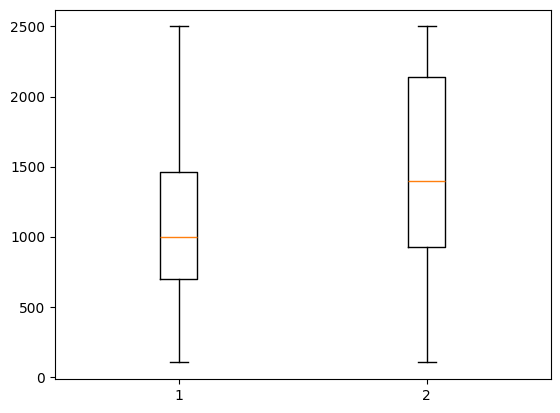

In [ ]:
#Lets do a quick box plot to see whats up and compare the means.
plt.figure()
plt.boxplot([bachelors['EARNWEEK2_w95'],masters['EARNWEEK2_w95']])
plt.show()

#Confidence Intervals
A **confidence interval** provides a range of plausible values for an unknown population parameter based on sample data.
In repeated samples, intervals constructed this way would contain the true parameter a specified percentage of the time (e.g., 95%), reflecting uncertainty due to sampling rather than variability among individuals.

$$
\bar{x} - z_{\alpha/2}\,\frac{s}{\sqrt{n}}
\;\le\;
\mu
\;\le\;
\bar{x} + z_{\alpha/2}\,\frac{s}{\sqrt{n}}
$$


We want to create a 95% Confidence Interval for the weekly earnings for people with masters and a 95% Confidence Interval for the weekly earnings for people with bachelors and see if the population means really are different (because then maybe we made a good decision).

In [ ]:
# Here we get all the "parts" to our equations - we need x_bar, s, n,z a/2
import numpy as np
import pandas as pd

# we need the mean (xbar) the sample size (n) and the sample standard deviation (s)
n=len(bachelors['EARNWEEK2_w95'])
mean_earn=bachelors['EARNWEEK2_w95'].mean()
std_earn=bachelors['EARNWEEK2_w95'].std()
print(n,mean_earn,std_earn)

26168 1130.0061143381229 596.7134141071148


scipy is a common stastical package for python.
We will use scipy to help us find $z_{\frac{\alpha}{2}}$


In [ ]:
# Lets find that z value and then we have the Margin of Error!!!
from scipy.stats import norm

z=norm.ppf(1-0.025)
ci_lower=mean_earn-z*(std_earn/np.sqrt(n))
ci_upper=mean_earn+z*(std_earn/np.sqrt(n))

print(ci_lower,ci_upper)
#we are 95% confident the population mean for bachelors falls within (1122,1137)

1122.7762753352545 1137.2359533409913


Let's do a quick review of hypothesis testing.
$$
H_0:\ \mu = \mu_0
\qquad
H_a:\ \mu \neq \mu_0
$$


$$
H_0:\ \mu \le \mu_0
\qquad
H_a:\ \mu > \mu_0
$$

$$
t \;=\;
\frac{\bar{x} - \mu_0}
{\frac{s}{\sqrt{n}}}
$$


$$
\text{Reject } H_0 \text{ if the p-value is sufficiently small.}
$$

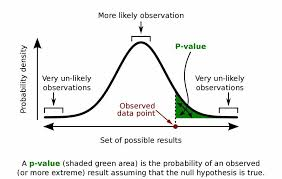

Independent Samples t-Test (ttest_ind) compares the means of two independent groups to determine whether the observed difference is likely due to random sampling variation or reflects a real difference in the population. The test produces a p-value that quantifies the strength of evidence against the null hypothesis that the two population means are equal.

### Hypothesis Test for an Independent Samples t-Test

$$
H_0:\ \mu_{\text{Bachelor}} = \mu_{\text{Graduate}}
$$

$$
H_1:\ \mu_{\text{Bachelor}} \neq \mu_{\text{Graduate}}$$

$$\text{could also be }\gt \text{or } \lt.$$


This test evaluates whether the difference in sample means provides sufficient evidence that the population means are not equal.


The notes only discuss a one sample t-test, but here we are comparing two samples. I explain this in class.

In [ ]:
from scipy.stats import ttest_ind,ttest_1samp
# We will compare do two hypothesis test to see if the Bachelors Wins Mean < 1140
# and one to see if the bachelors W Mean is less than the Masters Win Mean

#Ho: The mean for bachelors = 1140
#Ha: The mean for bachelors <1140

ttest_1samp(bachelors['EARNWEEK2_w95'],popmean=1140,alternative="less")
#Reject the null (there is enough data to reject the null in favor of the mean is less than 1140)
#Ho: bach = masters
#Ha: bach<masters

ttest_ind(bachelors['EARNWEEK2_w95'],masters['EARNWEEK2_w95'],alternative="less")
#reject the null

TtestResult(statistic=np.float64(-72.60868089164981), pvalue=np.float64(0.0), df=np.float64(87504.0))

What we did here is statistical inference, because we used sample data to draw conclusions about population-level parameters, specifically the difference in mean earnings between two groups. The t-test evaluates whether the observed difference in sample means provides evidence that the population means differ, not how well we can estimate any one individual’s earnings. Prediction focuses on forecasting individual outcomes using many features, whereas this analysis deliberately ignores individual variation to answer a single population-level question.